In [1]:
import warnings
warnings.filterwarnings('ignore')

import pickle, os, json, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import folium
from folium import plugins

OUTPUT_DIR = '../output'
plt.rcParams['figure.figsize'] = (13, 5)
sns.set_theme(style='whitegrid', font_scale=1.05)

# ── Load data dari Tahap 3 ───────────────────────────────────
with open(f'{OUTPUT_DIR}/tahap3_clustering.pkl', 'rb') as f:
    d = pickle.load(f)

BEST_DATASET    = d['BEST_DATASET']
BEST_K          = d['BEST_K']
BEST_SIL        = d['BEST_SIL']
BEST_LABELS     = d['BEST_LABELS']
CLUSTER_COLORS  = d['CLUSTER_COLORS']
meta_linear     = d['meta_linear']
meta_poly       = d['meta_poly']
X_linear        = d['X_linear']
X_poly          = d['X_poly']
df_hasil        = d['df_hasil']

# Hasil cluster terbaik untuk SETIAP dimensi (dibuat di Tahap 3 versi terbaru)
BEST_PER_DIM = d.get('BEST_PER_DIM')
if BEST_PER_DIM is None:
    raise KeyError('BEST_PER_DIM tidak ada di tahap3_clustering.pkl. '
                   'Jalankan ulang notebook Tahap 3 (versi terbaru) sampai sel terakhir, lalu ulangi Tahap 4.')
DIMENSI = d.get('DIMENSI', [204, 203, 74, 37])

meta_best = meta_linear if 'Linear' in BEST_DATASET else meta_poly
X_raw     = X_linear    if 'Linear' in BEST_DATASET else X_poly

print(f'Data Tahap 3 berhasil dimuat.')
print(f'  Konfigurasi terbaik: {BEST_DATASET}, k={BEST_K}, sil={BEST_SIL:.4f}')
print(f'  Jumlah wilayah     : {len(meta_best)}')
print(f'  Hasil per dimensi  : {len(BEST_PER_DIM)} konfigurasi ({", ".join(v["dataset"] for v in BEST_PER_DIM.values())})')

Data Tahap 3 berhasil dimuat.
  Konfigurasi terbaik: Poly-204, k=2, sil=0.5375
  Jumlah wilayah     : 37
  Hasil per dimensi  : 8 konfigurasi (Linear-204, Linear-203, Linear-74, Linear-37, Poly-204, Poly-203, Poly-74, Poly-37)


In [2]:

# ── Koordinat hardcoded (terverifikasi manual) ────────────────
KOORDINAT_DB = {
    'Baron Nganjuk'              : (-7.5083,  111.9167),
    'Nunukan'                    : ( 4.1333,  117.6667),
    'Sreseh, Sampang'            : (-7.1833,  113.2167),
    'Manyar, Gresik'             : (-7.1500,  112.6500),
    'Kamal, Bangkalan'           : (-7.1833,  112.7833),
    'Kedungpring Lamongan'       : (-7.3500,  112.2167),
    'Gresik Kota, Gresik'        : (-7.1556,  112.6527),
    'Waru, Pamekasan'            : (-7.1667,  113.4833),
    'Paciran, Lamongan'          : (-6.8667,  112.3333),
    'Kertosono, Nganjuk'         : (-7.5833,  112.1000),
}

# Koreksi manual untuk wilayah yang koordinatnya salah (mis. jatuh di Bali / Laut Jawa).
# Koordinat ini PERKIRAAN pada tingkat kecamatan/kabupaten, silakan periksa dan ubah bila perlu.
KOREKSI_MANUAL = {
    'Banyu Ajuh, Perumnas, Kamal': (-7.1833, 112.7833),   # Kamal, Bangkalan (sama dengan entri Kamal lain)
    'Bandung - Jogoroto, Jombang': (-7.5467, 112.2331),   # Kabupaten Jombang (perkiraan)
    'Kec. Kalianget, Sumenep'    : (-7.0583, 113.9333),   # Kalianget, Sumenep (perkiraan)
}

DEFAULT_KOORDINAT = (-7.5, 112.7)   # dipakai (dan diberi peringatan) jika koordinat tidak ditemukan
CACHE_FILE = f'{OUTPUT_DIR}/koordinat_cache.json'

# Load cache yang sudah ada
if os.path.exists(CACHE_FILE):
    with open(CACHE_FILE) as f:
        koordinat_cache = json.load(f)
    print(f'Cache dimuat: {len(koordinat_cache)} koordinat')
else:
    koordinat_cache = {}

# Terapkan koreksi manual (menimpa nilai lama di cache)
for nama_wil, coord in KOREKSI_MANUAL.items():
    koordinat_cache[nama_wil] = list(coord)
print(f'Koreksi manual diterapkan: {len(KOREKSI_MANUAL)} wilayah')

def get_koordinat(daerah: str):
    """Cari koordinat: cache -> hardcoded -> Nominatim. Mengembalikan (koordinat, sumber)."""
    if daerah in koordinat_cache:
        return tuple(koordinat_cache[daerah]), 'cache'
    for key, coord in KOORDINAT_DB.items():
        if key.lower() in daerah.lower() or daerah.lower() in key.lower():
            return coord, 'hardcoded'
    try:
        from geopy.geocoders import Nominatim
        from geopy.extra.rate_limiter import RateLimiter
        geo = Nominatim(user_agent='psd_cluster_2026')
        geocode = RateLimiter(geo.geocode, min_delay_seconds=1)
        loc = geocode(daerah + ', Indonesia')
        if loc:
            print(f'  Nominatim: {daerah} → ({loc.latitude:.4f}, {loc.longitude:.4f})')
            return (loc.latitude, loc.longitude), 'nominatim'
    except Exception as e:
        print(f'  Nominatim gagal ({daerah}): {e}')
    return DEFAULT_KOORDINAT, 'fallback'

# Geocode semua wilayah (gabungan Linear & Poly)
daftar_daerah = sorted(set(meta_linear['daerah']) | set(meta_poly['daerah']))
print(f'\nMengambil koordinat {len(daftar_daerah)} wilayah...')
fallback_list = []
for daerah in daftar_daerah:
    if daerah in koordinat_cache:
        continue
    coord, sumber = get_koordinat(daerah)
    if sumber == 'fallback':
        fallback_list.append(daerah)          # TIDAK disimpan ke cache
    else:
        koordinat_cache[daerah] = [coord[0], coord[1]]
        time.sleep(0.3)

# Simpan cache
with open(CACHE_FILE, 'w', encoding='utf-8') as f:
    json.dump(koordinat_cache, f, indent=2, ensure_ascii=False)
print(f'\nTotal koordinat: {len(koordinat_cache)} wilayah → disimpan ke cache')

if fallback_list:
    print('\nPERINGATAN: koordinat tidak ditemukan untuk wilayah berikut (diletakkan di titik default,')
    print('            tambahkan ke KOREKSI_MANUAL agar tampil di lokasi yang benar):')
    for nama_wil in fallback_list:
        print(f'   - {nama_wil}')


Cache dimuat: 35 koordinat
Koreksi manual diterapkan: 3 wilayah

Mengambil koordinat 36 wilayah...
  Nominatim gagal (Jabon , Sidoarjo): No module named 'geopy'

Total koordinat: 35 wilayah → disimpan ke cache

PERINGATAN: koordinat tidak ditemukan untuk wilayah berikut (diletakkan di titik default,
            tambahkan ke KOREKSI_MANUAL agar tampil di lokasi yang benar):
   - Jabon , Sidoarjo


In [3]:

# ── Gabungkan label cluster + koordinat untuk SETIAP dimensi ──
def buat_df_peta(info):
    metode = info['metode']
    meta   = (meta_linear if metode == 'Linear' else meta_poly).reset_index(drop=True)
    X_r    = X_linear if metode == 'Linear' else X_poly
    df = meta.copy()
    df['cluster'] = info['labels']
    df['lat'] = df['daerah'].map(lambda x: koordinat_cache.get(x, list(DEFAULT_KOORDINAT))[0])
    df['lon'] = df['daerah'].map(lambda x: koordinat_cache.get(x, list(DEFAULT_KOORDINAT))[1])
    for pol in ['no2', 'so2', 'co']:          # statistik polutan utama (mean)
        col_mean = f'{pol}_calc_mean'
        df[f'{pol}_mean'] = X_r[col_mean].values if col_mean in X_r.columns else np.nan
    return df

df_maps = {info['dataset']: buat_df_peta(info) for info in BEST_PER_DIM.values()}

# Konfigurasi terbaik global (dipakai sel peta statis tunggal)
df_map = df_maps[BEST_DATASET]

print('Ringkasan cluster terbaik per dimensi:')
for metode in ['Linear', 'Poly']:
    for dim in DIMENSI:
        info = BEST_PER_DIM.get((metode, dim))
        if info:
            print(f"  {info['dataset']:<11} k={info['k']}  sil={info['silhouette']:.4f}  ukuran cluster: {info['ukuran']}")

print(f'\nDataFrame peta konfigurasi terbaik global ({BEST_DATASET}):')
print(df_map[['daerah','cluster','lat','lon','no2_mean','so2_mean','co_mean']].to_string())


Ringkasan cluster terbaik per dimensi:
  Linear-204  k=2  sil=0.4909  ukuran cluster: [34, 3]
  Linear-203  k=2  sil=0.4909  ukuran cluster: [34, 3]
  Linear-74   k=2  sil=0.4021  ukuran cluster: [33, 4]
  Linear-37   k=2  sil=0.4021  ukuran cluster: [33, 4]
  Poly-204    k=2  sil=0.5375  ukuran cluster: [35, 2]
  Poly-203    k=2  sil=0.5375  ukuran cluster: [35, 2]
  Poly-74     k=3  sil=0.4543  ukuran cluster: [35, 1, 1]
  Poly-37     k=3  sil=0.4543  ukuran cluster: [35, 1, 1]

DataFrame peta konfigurasi terbaik global (Poly-204):
                           daerah  cluster       lat         lon  no2_mean  so2_mean   co_mean
0                   Baron Nganjuk        0 -7.508300  111.916700  0.000028  0.000072  0.030248
1                         Nunukan        0  4.133300  117.666700  0.000007 -0.000005  0.027691
2                 Sreseh, Sampang        0 -7.183300  113.216700  0.000027  0.000007  0.029516
3                  Manyar, Gresik        0 -7.150000  112.650000  0.000071  0.00

In [4]:
# ── Buat peta Folium ──────────────────────────────────────────
# CATATAN: tile CARTO ('CartoDB positron' / 'CartoDB dark_matter') sekarang wajib API key,
# tanpa key peta menampilkan watermark "API KEY REQUIRED". Karena itu basemap default diganti
# ke provider yang tidak memerlukan key (OpenStreetMap dan Esri).
m = folium.Map(
    location=[-2.5, 118.0],   # Pusat Indonesia
    zoom_start=5,
    tiles=None,               # basemap ditambahkan manual di bawah
    control_scale=True
)

folium.TileLayer('OpenStreetMap', name='OpenStreetMap (default)', show=True).add_to(m)

folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Street_Map/MapServer/tile/{z}/{y}/{x}',
    attr='Tiles &copy; Esri',
    name='Esri Street Map', show=False
).add_to(m)

folium.TileLayer(
    tiles='https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
    attr='Tiles &copy; Esri &mdash; Source: Esri, Maxar, Earthstar Geographics',
    name='Citra Satelit (Esri)', show=False
).add_to(m)

# OPSIONAL: aktifkan basemap CARTO jika Anda punya API key gratis (carto.com/basemaps/apikey).
# Simpan key di environment variable CARTO_API_KEY, jangan ditulis langsung di notebook.
CARTO_KEY = os.environ.get('CARTO_API_KEY', '')
if CARTO_KEY:
    carto_attr = ('&copy; <a href="https://www.openstreetmap.org/copyright">OpenStreetMap</a>, '
                  '&copy; <a href="https://carto.com/attributions">CARTO</a>')
    for estilo, nama in [('light_all', 'CARTO Light'), ('dark_all', 'CARTO Dark')]:
        folium.TileLayer(
            tiles=f'https://basemaps.cartocdn.com/rastertiles/{estilo}/{{z}}/{{x}}/{{y}}.png?key={CARTO_KEY}',
            attr=carto_attr, name=nama, show=False
        ).add_to(m)

# ── Satu FeatureGroup (layer) untuk setiap dimensi ───────────
def tambah_layer(peta, df, info, tampil):
    nama_layer = (f"{info['metode']} {info['dimensi']} dimensi  |  "
                  f"k={info['k']}, sil={info['silhouette']:.3f}")
    fg = folium.FeatureGroup(name=nama_layer, show=tampil)
    for _, row in df.iterrows():
        c   = int(row['cluster'])
        col = CLUSTER_COLORS[c % len(CLUSTER_COLORS)]

        no2_txt = f"{row['no2_mean']:.4f}" if pd.notna(row.get('no2_mean')) else 'N/A'
        so2_txt = f"{row['so2_mean']:.4f}" if pd.notna(row.get('so2_mean')) else 'N/A'
        co_txt  = f"{row['co_mean']:.4f}"  if pd.notna(row.get('co_mean'))  else 'N/A'

        popup_html = f"""
        <div style="font-family:'Segoe UI',Arial,sans-serif; min-width:220px; max-width:280px;">
          <div style="background:{col};color:white;padding:8px 12px;border-radius:6px 6px 0 0;">
            <b style="font-size:14px;">Cluster {c}</b>
          </div>
          <div style="padding:10px 12px;border:1px solid #eee;border-top:none;border-radius:0 0 6px 6px;">
            <table style="width:100%;border-collapse:collapse;font-size:12px;">
              <tr><td style="color:#777;padding:2px 0">Daerah</td><td><b>{row['daerah']}</b></td></tr>
              <tr><td style="color:#777;padding:2px 0">Nama</td><td>{row['nama']}</td></tr>
              <tr><td style="color:#777;padding:2px 0">Koordinat</td><td>{row['lat']:.4f}, {row['lon']:.4f}</td></tr>
              <tr><td colspan=2><hr style="margin:6px 0"></td></tr>
              <tr><td style="color:#1565C0;padding:2px 0">NO₂ mean</td><td><b>{no2_txt}</b></td></tr>
              <tr><td style="color:#B71C1C;padding:2px 0">SO₂ mean</td><td><b>{so2_txt}</b></td></tr>
              <tr><td style="color:#1B5E20;padding:2px 0">CO mean</td><td><b>{co_txt}</b></td></tr>
              <tr><td colspan=2><hr style="margin:6px 0"></td></tr>
              <tr><td style="color:#777">Dataset</td><td>{info['dataset']}</td></tr>
              <tr><td style="color:#777">k / Silhouette</td><td>{info['k']} / {info['silhouette']:.4f}</td></tr>
            </table>
          </div>
        </div>
        """

        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=14, color=col, fill=True,
            fill_color=col, fill_opacity=0.75, weight=2.5,
            popup=folium.Popup(popup_html, max_width=300),
            tooltip=f"{info['dataset']} | Cluster {c}: {row['daerah']}"
        ).add_to(fg)

        folium.Marker(
            location=[row['lat'], row['lon']],
            icon=folium.DivIcon(
                html=(f'<div style="font-size:9px;font-weight:bold;color:white;'
                      f'background:{col};border-radius:50%;width:22px;height:22px;'
                      f'display:flex;align-items:center;justify-content:center;'
                      f'box-shadow:0 2px 4px rgba(0,0,0,0.4);">C{c}</div>'),
                icon_size=(22, 22), icon_anchor=(11, 11)
            ),
            tooltip=row['daerah']
        ).add_to(fg)
    fg.add_to(peta)

n_layer = 0
for metode in ['Linear', 'Poly']:
    for dim in DIMENSI:
        info = BEST_PER_DIM.get((metode, dim))
        if info is None:
            continue
        tambah_layer(m, df_maps[info['dataset']], info, tampil=(info['dataset'] == BEST_DATASET))
        n_layer += 1

print(f'{n_layer} layer (dimensi) ditambahkan, masing-masing {len(df_map)} marker wilayah.')


8 layer (dimensi) ditambahkan, masing-masing 37 marker wilayah.


In [5]:
# ── Legenda HTML: ringkasan hasil di setiap dimensi ───────────
rows = ''
for metode in ['Linear', 'Poly']:
    for dim in DIMENSI:
        info = BEST_PER_DIM.get((metode, dim))
        if info is None:
            continue
        ukuran = ' / '.join(str(u) for u in info['ukuran'])
        bintang = ' ★' if info['dataset'] == BEST_DATASET else ''
        rows += (f'<tr><td style="padding:2px 8px 2px 0"><b>{info["dataset"]}</b>{bintang}</td>'
                 f'<td style="padding:2px 8px">k={info["k"]}</td>'
                 f'<td style="padding:2px 8px">{info["silhouette"]:.3f}</td>'
                 f'<td style="padding:2px 0">{ukuran}</td></tr>')

warna_items = ''.join(
    f'<span style="display:inline-flex;align-items:center;margin-right:8px;">'
    f'<span style="width:12px;height:12px;border-radius:50%;background:{CLUSTER_COLORS[c]};'
    f'margin-right:3px;"></span>C{c}</span>'
    for c in range(max(v['k'] for v in BEST_PER_DIM.values()))
)

legend_html = f"""
<div style="position:fixed;bottom:30px;left:30px;z-index:9999;
            background:white;padding:14px 18px;border-radius:10px;
            box-shadow:0 4px 15px rgba(0,0,0,0.2);
            font-family:'Segoe UI',Arial,sans-serif;font-size:11px;max-width:330px;">
  <div style="font-size:14px;font-weight:bold;margin-bottom:4px;">Cluster Terbaik per Dimensi</div>
  <div style="color:#777;margin-bottom:6px;">Pilih layer di kanan atas (★ = terbaik global)</div>
  <table style="border-collapse:collapse;">
    <tr style="color:#777;"><td>Dataset</td><td style="padding:0 8px">k</td><td style="padding:0 8px">Sil.</td><td>Ukuran cluster</td></tr>
    {rows}
  </table>
  <div style="margin-top:8px;color:#555;">{warna_items}</div>
</div>
"""
m.get_root().html.add_child(folium.Element(legend_html))

# Layer control
folium.LayerControl(collapsed=False, position='topright').add_to(m)

# Minimap
try:
    minimap = plugins.MiniMap(toggle_display=True, tile_layer='OpenStreetMap')
    m.add_child(minimap)
except Exception:
    pass

# Simpan peta
map_path = f'{OUTPUT_DIR}/peta_clustering_interaktif.html'
m.save(map_path)
print(f'Peta interaktif disimpan:')
print(f'  {os.path.abspath(map_path)}')
print(f'  Ukuran: {os.path.getsize(map_path)/1024:.0f} KB')

# Tampilkan di notebook
m

Peta interaktif disimpan:
  C:\Users\OKAN\OneDrive\Dokumen\PSD\materi\Clustering_Segmentasi\output\peta_clustering_interaktif.html
  Ukuran: 1073 KB


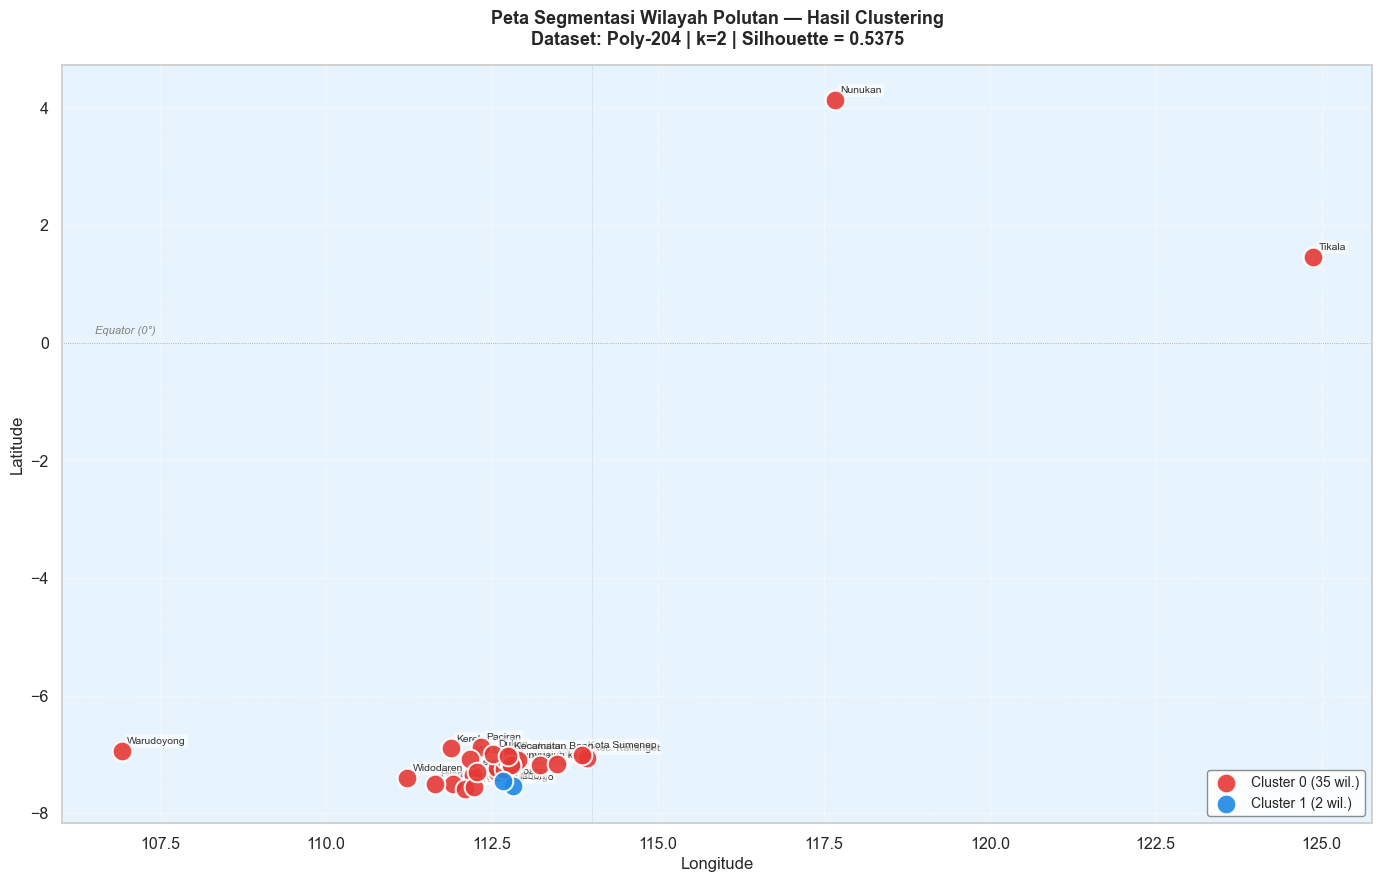

Peta statis disimpan: output/12_peta_statis.png


In [6]:
# ── Peta statis scatter ───────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 9))

for c in range(BEST_K):
    mask = df_map['cluster'] == c
    sub  = df_map[mask]
    ax.scatter(sub['lon'], sub['lat'],
               s=200, color=CLUSTER_COLORS[c],
               edgecolors='white', linewidth=1.5,
               label=f'Cluster {c} ({mask.sum()} wil.)',
               alpha=0.9, zorder=4)
    for _, row in sub.iterrows():
        ax.annotate(
            row['daerah'].split(',')[0][:14],
            xy=(row['lon'], row['lat']),
            xytext=(4, 5), textcoords='offset points',
            fontsize=7.5, color='#333',
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.6, linewidth=0)
        )

# Garis grid
ax.set_facecolor('#E8F4FD')
ax.grid(True, linestyle='--', alpha=0.4, color='white')

# Garis batas
ax.axhline(0, color='gray', linewidth=0.5, linestyle=':')
ax.axvline(114, color='gray', linewidth=0.5, linestyle=':', alpha=0.5)

ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title(f'Peta Segmentasi Wilayah Polutan — Hasil Clustering\n'
             f'Dataset: {BEST_DATASET} | k={BEST_K} | Silhouette = {BEST_SIL:.4f}',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(loc='lower right', fontsize=10, framealpha=0.9,
          edgecolor='gray', fancybox=True)

# Anotasi equator
ax.text(ax.get_xlim()[0]+0.5, 0.15, 'Equator (0°)',
        fontsize=8, color='gray', style='italic')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/12_peta_statis.png', dpi=150, bbox_inches='tight')
plt.show()
print('Peta statis disimpan: output/12_peta_statis.png')

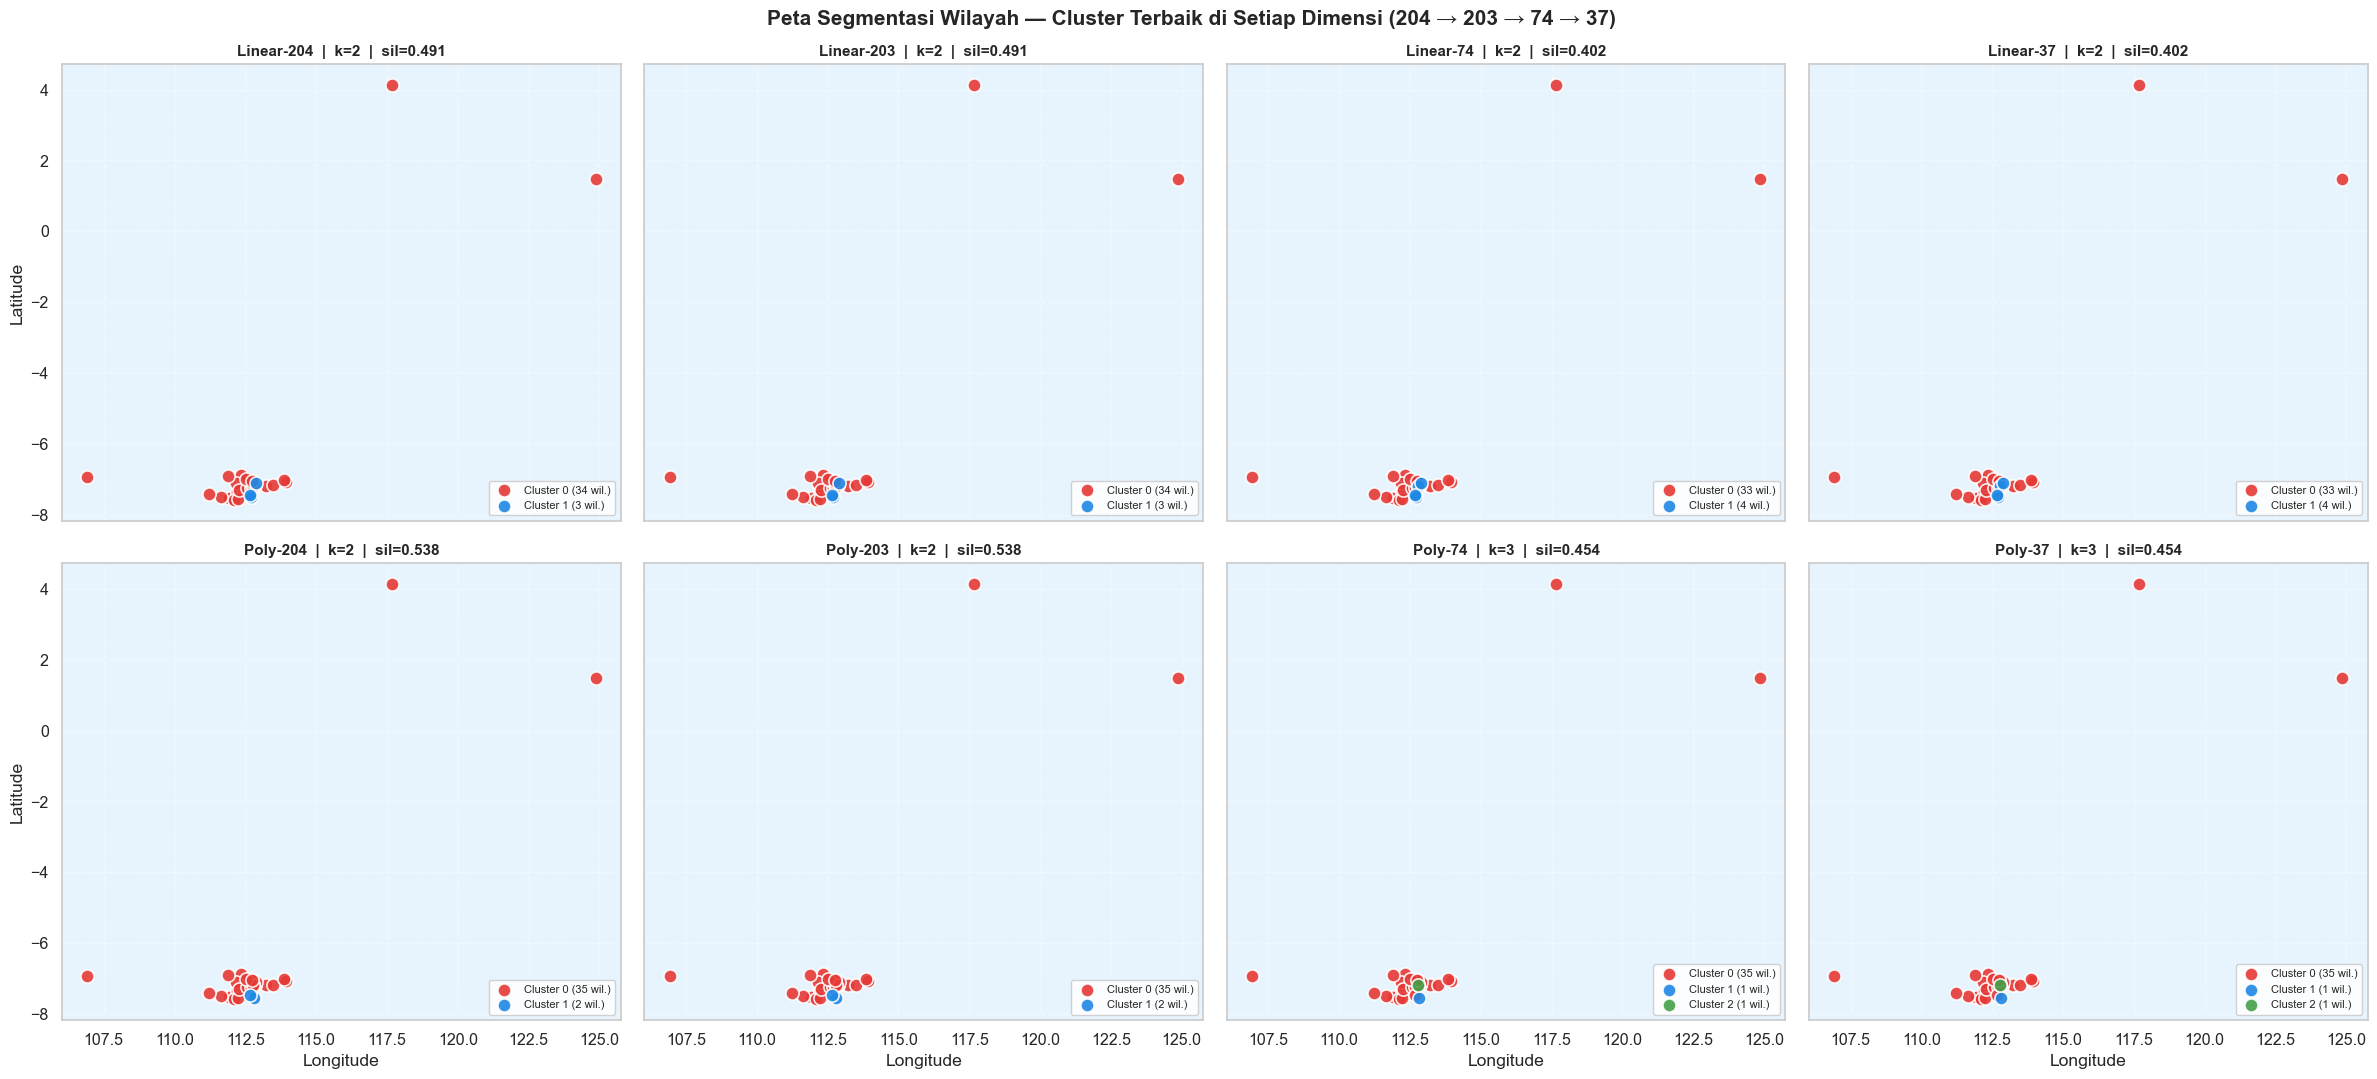

Peta statis per dimensi disimpan: output/13_peta_per_dimensi.png


In [7]:
# ── Peta statis: 2 baris (Linear, Poly) x 4 kolom (204, 203, 74, 37) ──
fig, axes = plt.subplots(2, 4, figsize=(24, 11), sharex=True, sharey=True)

for r, metode in enumerate(['Linear', 'Poly']):
    for ci, dim in enumerate(DIMENSI):
        ax   = axes[r, ci]
        info = BEST_PER_DIM.get((metode, dim))
        if info is None:
            ax.axis('off')
            continue
        df_p = df_maps[info['dataset']]
        for c in range(info['k']):
            sub = df_p[df_p['cluster'] == c]
            ax.scatter(sub['lon'], sub['lat'], s=90,
                       color=CLUSTER_COLORS[c % len(CLUSTER_COLORS)],
                       edgecolors='white', linewidth=1.2, alpha=0.9, zorder=4,
                       label=f'Cluster {c} ({len(sub)} wil.)')
        ax.set_facecolor('#E8F4FD')
        ax.grid(True, linestyle='--', alpha=0.4, color='white')
        ax.set_title(f"{info['dataset']}  |  k={info['k']}  |  sil={info['silhouette']:.3f}",
                     fontweight='bold', fontsize=11)
        ax.legend(loc='lower right', fontsize=8, framealpha=0.9)
        if r == 1:
            ax.set_xlabel('Longitude')
        if ci == 0:
            ax.set_ylabel('Latitude')

plt.suptitle('Peta Segmentasi Wilayah — Cluster Terbaik di Setiap Dimensi (204 → 203 → 74 → 37)',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/13_peta_per_dimensi.png', dpi=150, bbox_inches='tight')
plt.show()
print('Peta statis per dimensi disimpan: output/13_peta_per_dimensi.png')

In [8]:
# ── Cetak ringkasan lengkap ───────────────────────────────────
separator = '=' * 65
print(separator)
print(' RINGKASAN LENGKAP ANALISIS CLUSTERING SEGMENTASI POLUTAN')
print(separator)

print('\n[TAHAP 1] DATA & EDA')
print(f'  Sumber   : MySQL — basisda1_PSD-A-Interpolasi')
print(f'  Tabel    : ekstraksi_fitur_linear + ekstraksi_fitur_polynomial')
print(f'  Ukuran   : 37 wilayah × 204 fitur (68 per polutan)')

print('\n[TAHAP 2] REDUKSI DIMENSI')
print(f'  Standardisasi : StandardScaler (mean=0, std=1)')
print(f'  Urutan        : 204 → 203 → 74 → 37')
print(f'  204 → 203     : seleksi fitur (buang 1 fitur paling redundan)')
print(f'  203 → 74      : seleksi fitur (buang 129 fitur paling redundan)')
print(f'  74  → 37      : PCA (37 komponen)')

print('\n[TAHAP 3] EKSPERIMEN CLUSTERING')
print(f'  Algoritma     : K-Means (k-means++, n_init=20)')
print(f'  Variasi       : {df_hasil["dataset"].nunique()} dataset × k=2..10 = {len(df_hasil)} eksperimen')
print(f'  Evaluasi      : Silhouette Coefficient')
print(f'  Terbaik global: {BEST_DATASET}, k={BEST_K}, silhouette={BEST_SIL:.4f}')
print('\n  Cluster terbaik di setiap dimensi:')
for metode in ['Linear', 'Poly']:
    for dim in DIMENSI:
        info = BEST_PER_DIM.get((metode, dim))
        if info:
            print(f"    {info['dataset']:<11} k={info['k']}  sil={info['silhouette']:.4f}  "
                  f"ukuran: {' / '.join(str(u) for u in info['ukuran'])}")

print('\n[TAHAP 4] VISUALISASI PETA')
print(f'  Geocoding     : Nominatim (OpenStreetMap) + hardcoded')
print(f'  Peta interaktif : output/peta_clustering_interaktif.html')
print(f'  Peta statis     : output/12_peta_statis.png')
print(f'  Peta per dimensi: output/13_peta_per_dimensi.png')

print('\nDISTRIBUSI WILAYAH PER CLUSTER:')
print('-' * 65)
for c in range(BEST_K):
    mask = df_map['cluster'] == c
    wils = df_map[mask]['daerah'].tolist()
    print(f'\nCluster {c} ({len(wils)} wilayah) ─ warna: {CLUSTER_COLORS[c]}')
    for w in wils:
        print(f'   • {w}')

print('\n' + separator)
print(' OUTPUT FILES (folder output/)')
print(separator)
for fname in sorted(os.listdir(OUTPUT_DIR)):
    fpath = os.path.join(OUTPUT_DIR, fname)
    size  = os.path.getsize(fpath)
    print(f'  {fname:<45} {size/1024:6.1f} KB')
print('\n[SELESAI]')

 RINGKASAN LENGKAP ANALISIS CLUSTERING SEGMENTASI POLUTAN

[TAHAP 1] DATA & EDA
  Sumber   : MySQL — basisda1_PSD-A-Interpolasi
  Tabel    : ekstraksi_fitur_linear + ekstraksi_fitur_polynomial
  Ukuran   : 37 wilayah × 204 fitur (68 per polutan)

[TAHAP 2] REDUKSI DIMENSI
  Standardisasi : StandardScaler (mean=0, std=1)
  Urutan        : 204 → 203 → 74 → 37
  204 → 203     : seleksi fitur (buang 1 fitur paling redundan)
  203 → 74      : seleksi fitur (buang 129 fitur paling redundan)
  74  → 37      : PCA (37 komponen)

[TAHAP 3] EKSPERIMEN CLUSTERING
  Algoritma     : K-Means (k-means++, n_init=20)
  Variasi       : 8 dataset × k=2..10 = 72 eksperimen
  Evaluasi      : Silhouette Coefficient
  Terbaik global: Poly-204, k=2, silhouette=0.5375

  Cluster terbaik di setiap dimensi:
    Linear-204  k=2  sil=0.4909  ukuran: 34 / 3
    Linear-203  k=2  sil=0.4909  ukuran: 34 / 3
    Linear-74   k=2  sil=0.4021  ukuran: 33 / 4
    Linear-37   k=2  sil=0.4021  ukuran: 33 / 4
    Poly-204    